### This notebook is for plotting the main figures used in the SOPO report/presentation. Specific notebooks where calculations can be found are listed below

In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
from salishsea_tools import viz_tools, places, visualisations
from matplotlib import pyplot as plt, dates
from datetime import datetime, timedelta
from calendar import month_name
from scipy.io import loadmat
from tqdm.notebook import tqdm
from salishsea_tools import nc_tools
from dask.diagnostics import ProgressBar
import cmocean

%matplotlib inline

In [2]:
from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>

<form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')

In [3]:
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 'medium'})

## Import NPGO Index file

In [4]:
## Can either import NPGO values or calculate annual values elsewhere and create an array for plotting. 

df = pd.read_csv('/ocean/ksuchy/MOAD/analysis-karyn/notebooks/SOPO/SOPO_2025/NPGO.csv', index_col=0,header=0)

In [5]:
df.index.name = "YEAR"
df = df.apply(pd.to_numeric) # convert all columns of DataFrame
#df = df[:-1]

### Select years 2007 to 2023 for SOPO report

In [6]:
df.loc[2007:2026]

,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
YEAR,,,,,,,,,,,,
2007,-0.243309,-0.729927,-0.182149,0.384615,0.144928,1.230000,1.230000,1.430000,0.110011,1.270000,0.137363,0.218341
2008,0.179856,1.140000,1.370000,1.400000,1.740000,1.280000,1.430000,2.140000,2.230000,1.770000,1.970000,0.227273
2009,0.138313,0.110011,0.302115,0.240385,0.180180,0.270270,0.178571,0.139276,0.102669,1.150000,1.050000,1.060000
2010,2.060000,1.840000,1.650000,1.180000,1.870000,1.240000,1.150000,1.080000,1.000000,1.610000,0.101215,0.128370
2011,0.310559,0.181818,1.200000,0.167785,1.390000,1.110000,1.040000,1.040000,1.330000,1.200000,0.267380,0.757576
2012,0.119904,0.115875,1.120000,1.930000,1.630000,1.940000,1.860000,1.730000,1.360000,1.870000,1.400000,1.200000
2013,1.230000,1.200000,0.155521,0.210084,0.117371,0.137552,0.221729,0.195312,0.256410,-0.680272,-0.124224,-1.450000
2014,-0.256410,-0.374532,-0.220264,-0.161812,0.440529,-0.239808,-0.746269,-0.183486,-0.128700,0.235849,0.320513,-0.280899
2015,-0.181488,-1.270000,-1.400000,-1.380000,-0.138889,-1.250000,-1.470000,-1.930000,-2.100000,-1.310000,-2.250000,-1.110000


In [7]:
NPGO = df.loc[2007:2026].to_numpy().flatten()

### Get date into proper format

In [8]:
date = []
for year in range(2007, 2025):
    for month in range(1, 13):
        index = df.index == str(year)
        date.append(datetime(year, month, 1))
        
        

date = np.array(date)
#NPGO = df.loc[2007:2020].to_numpy().flatten()
#Nitrate_Anom = df2.to_numpy().flatten()

## Plot NPGO Index vs. monthly Central SoG diatom anomalies

In [12]:
## Annual NPGO values
NPGO_Annual=[0.416655983,
1.406427404,
0.410149171,
1.242465357,
0.832926488,
1.356314911,
0.122457003,
-0.132940854,
-1.315864758,
-0.030001073,
-0.570698404,
-1.901666667,
-2.188857716,
-1.558333333,
-0.884166667,
-1.2475,
-1.723333333,
-1.936666667,
-2.678333333] 

In [13]:
## Values are from calculations in Diatoms_SOPO2025_CentralSoG_v202111.ipynb

Diatom_Critical_Anom=[0.9587065146964662,
                      3.785497592122365,
                      0.8896491349344053,
                      3.4246816726590907,
                      0.03985877809441973,
                      2.6829948384908633,
                      1.9587023692838912,
                      -2.231737575765452,
                      -2.0549345185938357,
                      0.2508894109322881,
                      -1.9942306040694913,
                      -2.29230019142663,
                      -0.6503592176858035,
                      -2.5310264467240593,
                      -1.7844261839645608,
                      -1.2502707398637156,
                      -0.7150275183785162,
                      0.5480416700217923,
                      0.9652910152364171]




In [16]:
## Values are from calculations in Winds2007-2025_CentralSoGonly.ipynb

Spring_Wind_Anom=[0.313348356567527,
                  0.16326290734877702,
                  0.5397550897625143,
                  0.5411509510702945,
                  0.5330507593181784,
                  0.6028301553753073,
                  -0.043610668497576555,
                  0.04235417016615983,
                  -0.4321954412433451,
                  0.2583057718303854,
                  -0.1478838287962425,
                  -0.7762175563149598,
                  -0.3038111689858578,
                  -0.41522893937160044 ,
                  -0.05239877732326015,
                  -0.29358015091945155,
                  -0.44797847381780986,
                  0.055188574991922756,
                  -0.13634173116096804]

In [17]:
## Values are from calculations in SST_SOPO2025_CentralSoG_v202111.ipynb

Spring_SST_Anom=[0.08808263436019104,
                 -0.809850172326934,
                 -0.22004180549952146 ,
                 -0.772601040925716,
                 -0.8886991054962401,
                 -1.1271376007793013,
                 -0.15047574437582512 ,
                 0.3303583044416083 ,
                 0.9766025278014236,
                 0.9582753128039467,
                 -0.035462680843830086,
                 0.6169147529485954,
                 0.4650382279883303,
                 0.2999951688896907,
                 0.4669688583361733,
                 -0.5781209388952817,
                 0.4192467963329669,
                 -0.2774291455728779,
                 0.23833565081259245
                ]

## Plot Annual NPGO Index vs. Spring SST and Wind Anomalies

In [19]:
from matplotlib.ticker import FormatStrFormatter

Text(0, 0.5, 'SST (Degrees C)')

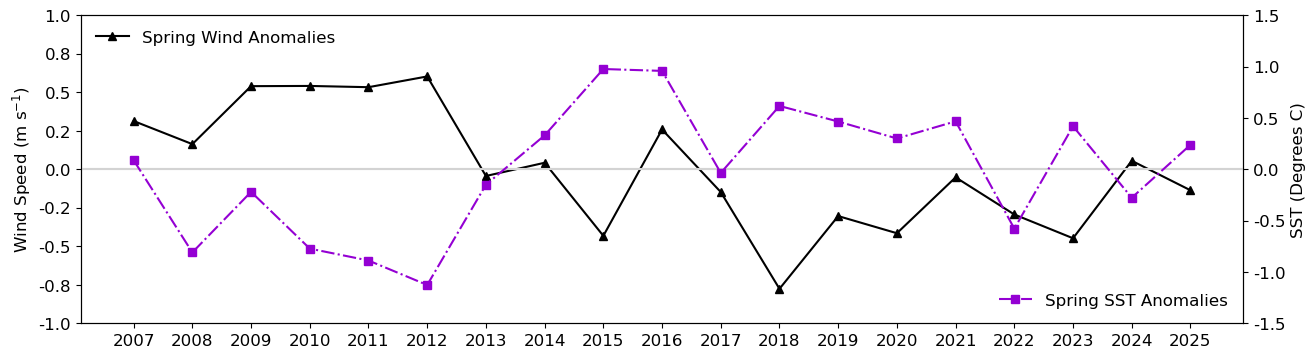

In [20]:
fig, ax1 = plt.subplots(figsize=(15, 4))
x=['2007','2008','2009','2010','2011','2012','2013','2014',
   '2015','2016','2017','2018','2019','2020','2021','2022','2023','2024','2025']

ax2 = ax1.twinx()

ax1.plot(x, Spring_Wind_Anom,marker='^',label='Spring Wind Anomalies',color='k',zorder=5)
ax2.plot(x, Spring_SST_Anom,marker='s',linestyle='-.',label='Spring SST Anomalies',color='darkviolet',zorder=5)
ax1.set_title('',fontsize=18)  #(with 2015)
ax1.legend(frameon=False,loc=2,fontsize=12)
ax1.set_ylim(-1,1)
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax1.set_ylabel('Wind Speed (m s$^{-1}$)',fontsize=12,)
ax1.axhline(y=0,color='lightgrey',linestyle='-',zorder=1)

ax2.axhline(y=0,color='lightgrey',linestyle='-',zorder=1)
ax2.legend(frameon=False,loc=4,fontsize=12)
ax2.set_ylim(-1.5,1.5)
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax2.set_ylabel('SST (Degrees C)',fontsize=12)

## Plot Annual NPGO Index vs. Spring SST and Wind Anomalies & May-July Diatom Anomalies

(-6.0, 6.0)

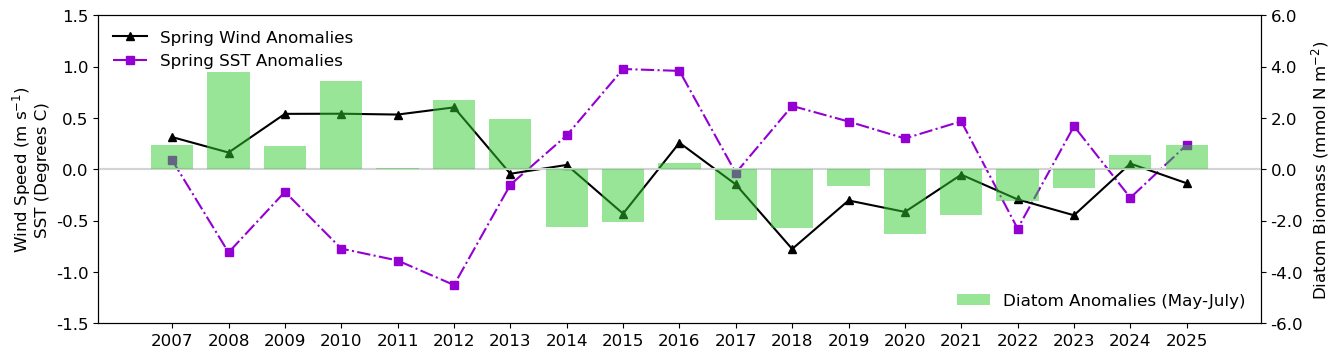

In [21]:
fig, ax1 = plt.subplots(figsize=(15, 4))
x=['2007','2008','2009','2010','2011','2012','2013',
   '2014','2015','2016','2017','2018','2019','2020','2021','2022','2023','2024','2025']

ax2 = ax1.twinx()

ax1.plot(x, Spring_Wind_Anom,marker='^',label='Spring Wind Anomalies',color='k',zorder=100)
ax1.plot(x, Spring_SST_Anom,marker='s',linestyle='-.',label='Spring SST Anomalies',color='darkviolet',zorder=70)
ax1.set_title('',fontsize=18)  #(with 2015)
ax1.legend(frameon=False,loc=2,fontsize=12)
ax1.set_ylim(-1.5,1.5)
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax1.set_ylabel('Wind Speed (m s$^{-1}$)\nSST (Degrees C)',fontsize=12,)
ax1.axhline(y=0,color='lightgrey',linestyle='-')

ax2.bar(x, Diatom_Critical_Anom,color='limegreen',alpha=0.5,width=.75,zorder=50,label='Diatom Anomalies (May-July)')
ax2.legend(frameon=False,loc=4,fontsize=12)
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax2.axhline(y=0,color='lightgrey',linestyle='-')
ax2.set_ylabel('Diatom Biomass (mmol N m$^{-2}$)',fontsize=12,)
ax2.set_ylim(-6,6)

## Plot Annual NPGO Index vs. Critical Period for salmon (May-Jun) Diatom Anomalies

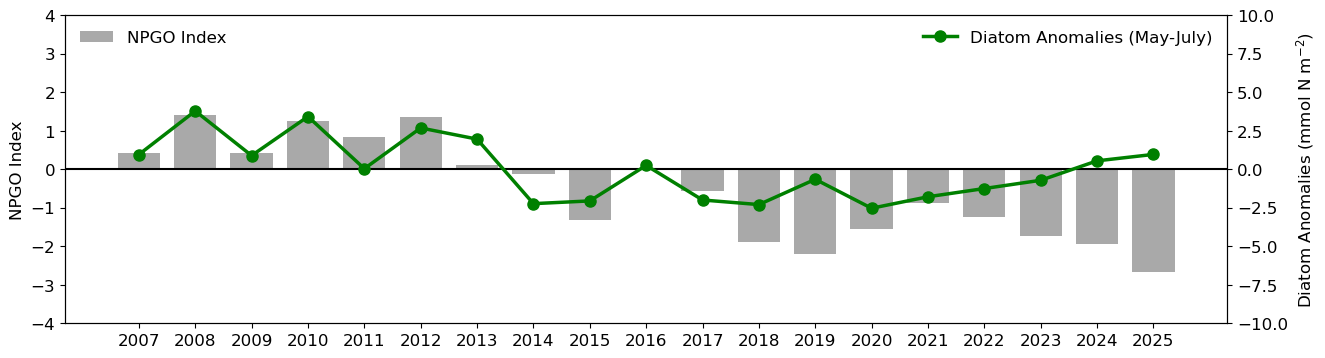

In [23]:
fig, ax1 = plt.subplots(figsize=(15, 4))
x=['2007','2008','2009','2010','2011','2012','2013','2014','2015',
   '2016','2017','2018','2019','2020','2021','2022','2023','2024','2025']

ax2 = ax1.twinx()
ax1.bar(x, NPGO_Annual, width=.75, color='darkgrey',label='NPGO Index')
#ax.bar(df3.index['NPGO_May_Anomalies'<0], df3['NPGO_May_Anomalies'<0], width=20, color='r',label='NPGO- (warm)')
ax1.set_ylim(-4,4)
ax2.plot(x,Diatom_Critical_Anom,color='green',marker='o',markersize=8,linewidth=2.5,label='Diatom Anomalies (May-July)')
ax2.set_ylim(-10,10)
ax1.set_ylabel('NPGO Index')
ax2.set_ylabel('Diatom Anomalies (mmol N m$^{-2}$)')
ax1.axhline(y=0,color='k')
#ax1.set_title('Annual NPGO Index vs. May-July Diatom Anomalies',fontsize=18)
ax1.legend(frameon=False,loc=2)
ax2.legend(frameon=False,loc=1)